In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
import time
import os
from glob import glob

In [3]:
save_dir = '/content/drive/MyDrive/Midterm_23070471_Nguyen_Tuan_Minh/Data/Part_a'
os.makedirs(save_dir, exist_ok=True)

Processing: img1.jpg


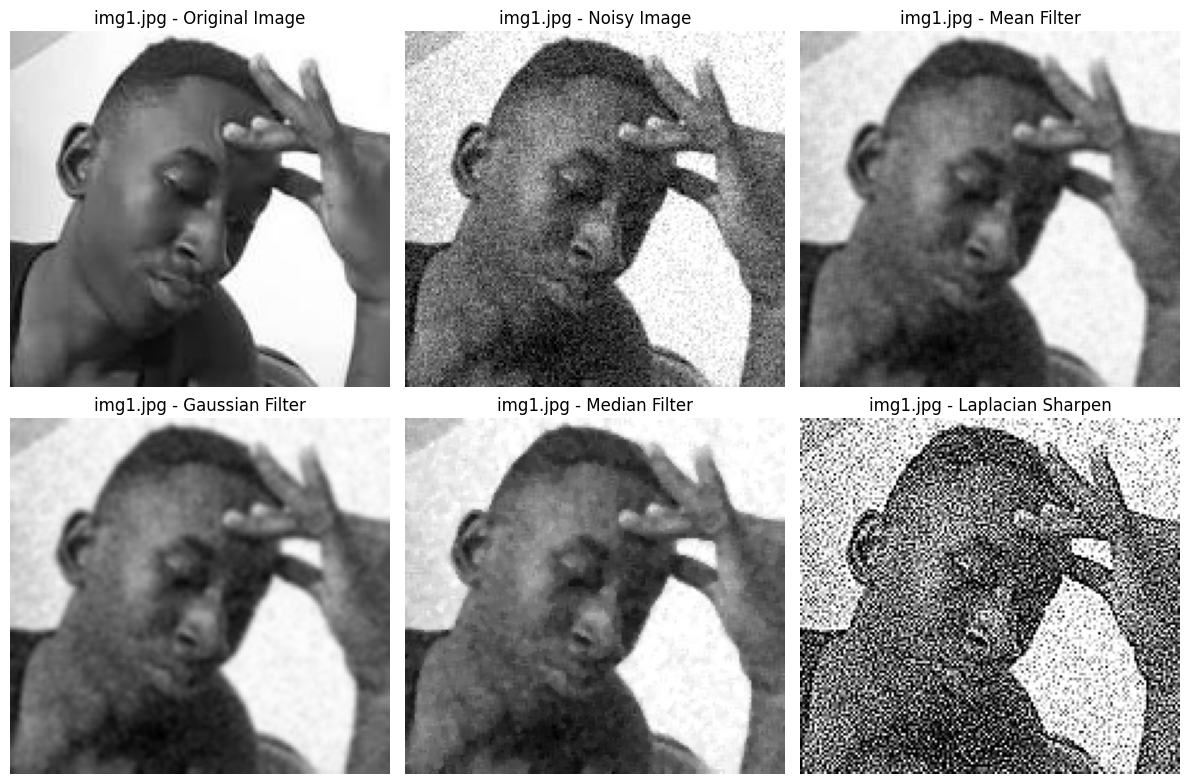

Processing: img2.jpg


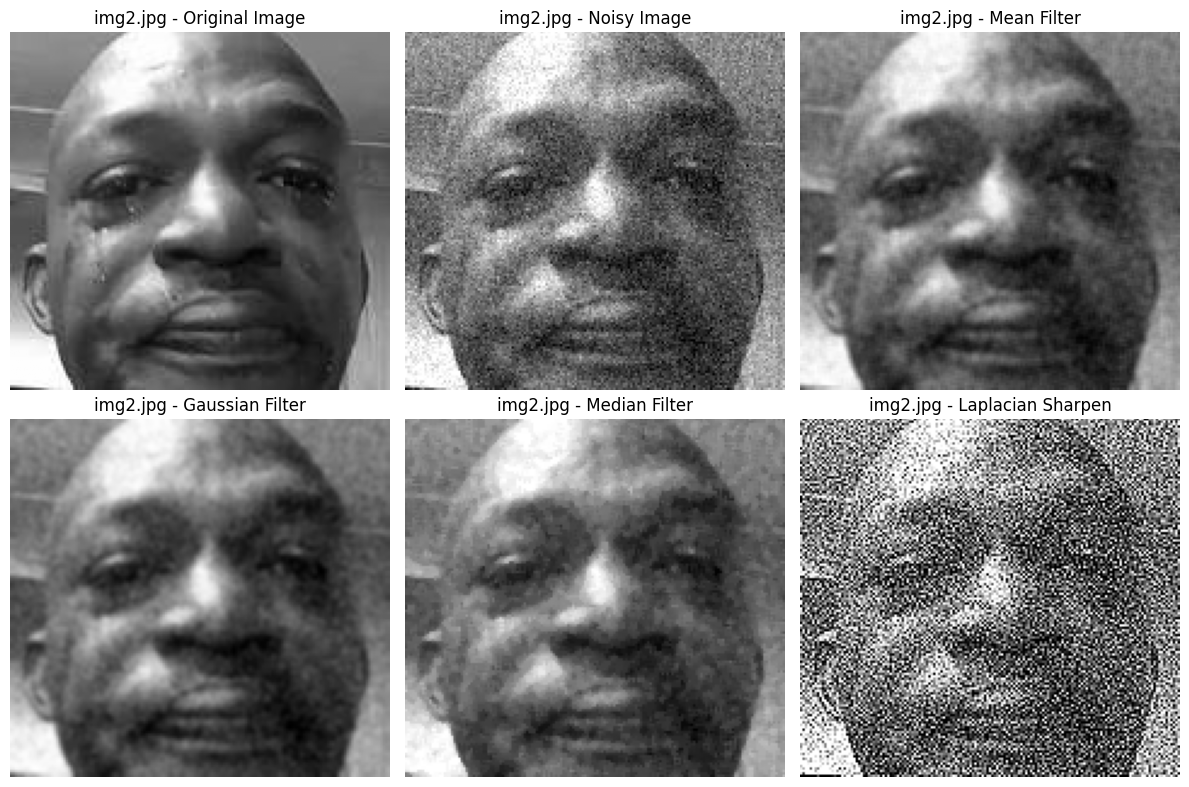

Done!


In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from glob import glob
input_dir = "/content/drive/MyDrive/Midterm_23070471_Nguyen_Tuan_Minh/Data/Part_a"
output_dir = "/content/drive/MyDrive/Midterm_23070471_Nguyen_Tuan_Minh/Results/Part_a"
os.makedirs(output_dir, exist_ok=True)
def pad_image(img, pad):
    return np.pad(img, ((pad,pad),(pad,pad)), mode='reflect')
def mean_filter(img, k=3):
    pad = k//2
    padded = pad_image(img, pad)
    h, w = img.shape
    output = np.zeros_like(img, dtype=np.float32)

    for i in range(h):
        for j in range(w):
            region = padded[i:i+k, j:j+k]
            output[i,j] = np.mean(region)

    return np.clip(output,0,255).astype(np.uint8)

def gaussian_kernel(k=5, sigma=1):
    ax = np.arange(-k//2 + 1., k//2 + 1.)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2)/(2*sigma**2))
    return kernel / np.sum(kernel)

def gaussian_filter(img, k=5, sigma=1):
    kernel = gaussian_kernel(k, sigma)
    pad = k//2
    padded = pad_image(img, pad)
    h, w = img.shape
    output = np.zeros_like(img, dtype=np.float32)

    for i in range(h):
        for j in range(w):
            region = padded[i:i+k, j:j+k]
            output[i,j] = np.sum(region * kernel)

    return np.clip(output,0,255).astype(np.uint8)

def median_filter(img, k=3):
    pad = k//2
    padded = pad_image(img, pad)
    h, w = img.shape
    output = np.zeros_like(img)

    for i in range(h):
        for j in range(w):
            region = padded[i:i+k, j:j+k]
            output[i,j] = np.median(region)

    return output

def laplacian_filter(img):
    kernel = np.array([[0,-1,0],
                       [-1,4,-1],
                       [0,-1,0]])

    pad = 1
    padded = pad_image(img, pad)
    h, w = img.shape
    output = np.zeros_like(img, dtype=np.float32)

    for i in range(h):
        for j in range(w):
            region = padded[i:i+3, j:j+3]
            output[i,j] = np.sum(region * kernel)

    sharpen = img + output
    return np.clip(sharpen,0,255).astype(np.uint8)


image_paths = glob(os.path.join(input_dir, "*"))

for path in image_paths:

    filename = os.path.basename(path)
    name, ext = os.path.splitext(filename)

    print("Processing:", filename)

    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)


    noise = np.random.normal(0, 20, img.shape)
    noisy = np.clip(img + noise,0,255).astype(np.uint8)


    mean_img = mean_filter(noisy)
    gauss_img = gaussian_filter(noisy)
    median_img = median_filter(noisy)
    laplace_img = laplacian_filter(noisy)


    save_dir = os.path.join(output_dir, name)
    os.makedirs(save_dir, exist_ok=True)


    cv2.imwrite(os.path.join(save_dir,"original.png"), img)
    cv2.imwrite(os.path.join(save_dir,"noisy.png"), noisy)
    cv2.imwrite(os.path.join(save_dir,"mean.png"), mean_img)
    cv2.imwrite(os.path.join(save_dir,"gaussian.png"), gauss_img)
    cv2.imwrite(os.path.join(save_dir,"median.png"), median_img)
    cv2.imwrite(os.path.join(save_dir,"laplacian.png"), laplace_img)

    combined = np.hstack((img,noisy,mean_img,gauss_img,median_img,laplace_img))
    cv2.imwrite(os.path.join(save_dir,"comparison.png"), combined)


    titles = [
        "Original Image",
        "Noisy Image",
        "Mean Filter",
        "Gaussian Filter",
        "Median Filter",
        "Laplacian Sharpen"
    ]

    images = [img, noisy, mean_img, gauss_img, median_img, laplace_img]

    plt.figure(figsize=(12,8))
    for i in range(6):
        plt.subplot(2,3,i+1)
        plt.imshow(images[i], cmap='gray')
        plt.title(f"{filename} - {titles[i]}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

print("Done!")

In [6]:
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

def compute_metrics(original, filtered):
    p = psnr(original, filtered)
    s = ssim(original, filtered)
    return p, s

In [7]:
mean_img = mean_filter(noisy)
gauss_img = gaussian_filter(noisy)
median_img = median_filter(noisy)
laplace_img = laplacian_filter(noisy)

In [8]:
# === COMPUTE METRICS ===
filters = {
    "Mean": mean_img,
    "Gaussian": gauss_img,
    "Median": median_img,
    "Laplacian": laplace_img
}

print("\n=== METRICS ===")
for name, f_img in filters.items():
    p, s = compute_metrics(img, f_img)
    print(f"{name}: PSNR={p:.2f}, SSIM={s:.4f}")


=== METRICS ===
Mean: PSNR=29.14, SSIM=0.8032
Gaussian: PSNR=29.72, SSIM=0.8350
Median: PSNR=28.01, SSIM=0.7443
Laplacian: PSNR=9.90, SSIM=0.0817


In [9]:
with open(os.path.join(save_dir, "metrics.txt"), "w") as f:
    for name, f_img in filters.items():
        p, s = compute_metrics(img, f_img)
        f.write(f"{name}: PSNR={p:.2f}, SSIM={s:.4f}\n")

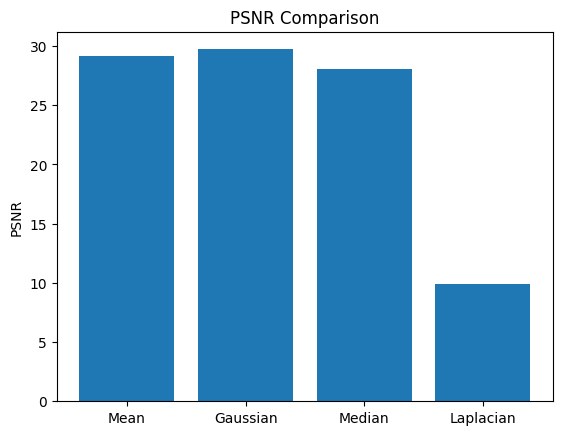

In [10]:
names = list(filters.keys())
psnr_vals = [compute_metrics(img, filters[n])[0] for n in names]

plt.figure()
plt.bar(names, psnr_vals)
plt.title("PSNR Comparison")
plt.ylabel("PSNR")
plt.savefig(os.path.join(save_dir, "/content/drive/MyDrive/Midterm_23070471_Nguyen_Tuan_Minh/Results/Comparison/psnr_chart.png"))
plt.show()